# 🎓 OPD 在策略蒸馏实战：让 Qwen3-0.6B 学会通用推理与指令跟随

> ** 给桔梗姐姐的开源蒸馏教程** —— 全部使用开源模型与开源数据，可在具备足够显存的 GPU 环境中运行。
> 
> 本教程复现 **On-Policy Distillation（OPD，在策略蒸馏）** 训练范式：用 **Qwen3-4B** 做教师，
> 对 **Qwen3-0.6B** 学生**自己生成的回答**逐 token 打分，让学生在"自己会走到的状态"上向教师对齐。

| 项目 | 内容 |
|---|---|
| 🧑‍🎓 学生模型 | `Qwen/Qwen3-0.6B`（LoRA 微调） |
| 🧑‍🏫 教师模型 | `Qwen/Qwen3-4B`（4bit 量化，只前向打分） |
| 📚 训练数据 | `openai/gsm8k`（数学推理）——**只需要 prompt** |
| 📏 评估 | GSM8K test 准确率（训练前后对比）+ 定性生成对比 |

**目录**
1. OPD 是什么：SFT / RL / OPD 三种范式的对比
2. 环境安装与实验配置
3. 加载学生与教师模型
4. 准备 prompt 数据（OPD 只需要题目，不需要答案！）
5. OPD 核心算法（约 30 行核心代码）
6. 训练前基线评估
7. OPD 训练循环
8. 训练后评估与前后对比
9. 保存、合并与 GGUF 导出
10. 附录：TRL GKD 替代方案 / 超参调优 / 参考文献

## 1️⃣ OPD 是什么？

训练小模型有三条经典路线。**OPD（On-Policy Distillation，在策略蒸馏）** 结合了另外两者的优点：

| 方法 | 采样来源 | 监督信号 | 问题 |
|---|---|---|---|
| **SFT（离策略蒸馏）** | 教师写的标准答案 | 稠密（逐 token） | 学生只见过"教师会走到的状态"，一旦自己犯错就不会恢复（复合错误 / compounding error） |
| **RL（强化学习）** | 学生自己生成 | 稀疏（整条答案一个分数） | 反馈太粗：答案错了，但不知道错在哪一步，样本效率低 |
| **OPD（在策略蒸馏）** | **学生自己生成** | **稠密（教师逐 token 打分）** | ✅ 既在学生的真实分布上训练，又有逐 token 的精细反馈 |

♟️ **象棋比喻**（来自 Thinking Machines Lab）：
- SFT = 反复观看棋圣的对局录像——招数很强，但局面都不是你会走到的；
- RL = 自己下棋，只告诉你最终输赢；
- **OPD = 你自己下棋，教练对你的每一步都打分（"妙手/失误/败着"）**。

### 数学形式：逐 token 的 reverse KL

学生在自己的轨迹 $x_{1..T}$ 上，每个位置计算与教师分布的 **reverse KL**：

$$\text{KL}(\pi_\theta \| \pi_{teacher}) = \mathbb{E}_{x \sim \pi_\theta}\left[ \log \pi_\theta(x_{t+1}|x_{1..t}) - \log \pi_{teacher}(x_{t+1}|x_{1..t}) \right]$$

把 **负的逐 token KL 当作 reward（advantage）**，套用一个标准的 PPO 式策略梯度更新即可。

用 Thinking Machines 的话说：**这相当于把 RL 实现里的 KL 正则项参考模型换成教师模型——一行改动**。

### 为什么值得学？

- 📈 **Qwen3 官方技术报告**：OPD 用 RL **十分之一** 的算力，把 AIME'24 从 67.6% 推到 **74.4%**（RL 只有 67.6%，且多花约 9 倍 GPU 时）。
- 💰 **省钱**：教师只需对短轨迹做一次前向（拿 logprobs），不需要写完整个 rollout 才算 reward，也不要独立的奖励模型。
- 🧲 **reverse KL 是 mode-seeking 且不可 hack 的**：KL 低必然意味着学生真的像教师，不存在 reward hacking。

> 📖 本教程的算法与 Thinking Machines Lab《On-Policy Distillation》博客及 Tinker cookbook 一致；
> 
> 工程组织方式参考了 jackrong 的 Qwopus 系列教程（开源数据、LoRA + GGUF 导出全流程）。

## 2️⃣ 实验设计总览

```
                 ┌─────────────────────────────────────────────────────┐
                 │                每个 OPD 训练步                        │
                 │                                                     │
  prompt 批次 ──▶│  ① 学生采样：Qwen3-0.6B 自己回答（记录每 token logp） │
  (no_robots     │  ② 教师打分：Qwen3-4B 对学生轨迹前向一次 → 教师 logp  │
   + gsm8k)      │  ③ 逐 token reverse KL = logp_student − logp_teacher │
                 │  ④ advantage = −KL，PPO 式更新学生（教师冻结）        │
                 └─────────────────────────────────────────────────────┘
```

**关键设计决策：**

| 决策 | 选择 | 原因 |
|---|---|---|
| 学生初始化 | `Qwen3-0.6B`（instruct 版） | OPD 适合"有基础能力"的模型，reverse KL 在已有支撑集内做 mode-seeking |
| 教师 | `Qwen3-4B` | 通用推理 + 指令跟随强；非思考型，回答长度可控；同家族 **tokenizer 一致**（逐 token 对齐的前提！） |
| 教师加载 | 4bit NF4 量化 | 只前向打分，无需梯度，可降低显存占用 |
| 学生训练 | LoRA (r=16) | 教学友好、显存省；附录给出全量微调建议 |
| 采样温度 | 1.0（不做 top-p 截断） | 严格 on-policy：行为分布 = 当前策略分布，重要性比率干净 |
| 数据 | 只用 prompt | OPD 的精髓：答案由学生写、教师当场批改，**不需要任何人工/教师标注的答案** |

> ⚠️ 前向激活与 logits 采用**分块（chunk）**计算以控制显存占用；实际需求取决于 batch、序列长度和所用 GPU。

## 3️⃣ 环境安装

> 请根据当前 GPU 环境安装依赖；安装约 1-2 分钟，装完按提示重启运行时（如有）。

In [1]:
# !pip uninstall -y vllm xformers torch torchvision torchaudio
# !pip install --no-cache-dir torch==2.6.0 torchvision==0.21.0 torchaudio==2.6.0 --index-url https://download.pytorch.org/whl/cu124
# !pip install --no-cache-dir vllm==0.8.5 transformers==4.57.3 peft==0.20.0 accelerate==1.12.0 datasets==4.8.5 bitsandbytes==0.50.1 nvidia-ml-py==13.610.43

## 4️⃣ 实验配置

所有超参数集中在这里。默认配置适合先运行一个小规模实验；
想复现更强的效果，可按第 10 节附录的建议增加训练规模。

In [2]:
from dataclasses import dataclass, field
import torch

@dataclass
class OPDConfig:
    # ---- 模型 ----
    student_name: str = "Qwen/Qwen3-0.6B"                 # 学生：LoRA 微调
    teacher_name: str = "Qwen/Qwen3-4B"     # 教师：4bit 冻结打分

    # ---- 数据 ----
    n_math_prompts: int = 7473            # 使用完整 GSM8K train split
    max_prompt_len: int = 512             # 超长 prompt 截断

    # ---- 采样（on-policy rollout）----
    batch_prompts: int = 4                 # 每步 prompt 数
    max_new_tokens: int = 512             # 给数学推理更长的 rollout 空间
    sample_temperature: float = 1.0       # 严格 on-policy：不做 top-p 截断

    # ---- OPD 训练 ----
    lr: float = 1e-5                      # 延长训练时使用更保守的学习率
    steps: int = 400                       # 增加优化步数
    inner_epochs: int = 2                 # 同批 rollout 重复利用次数（PPO epoch）
    clip_eps: float = 0.2                 # PPO clip
    teacher_chunk: int = 4                # 教师打分时的分块大小（省显存）
    sft_warmup_steps: int = 50            # 覆盖更多教师数学轨迹
    sft_batch_prompts: int = 4            # 教师生成峰值高，warm-up 独立使用小 batch

    # ---- LoRA ----
    lora_r: int = 16
    lora_alpha: int = 32
    lora_dropout: float = 0.0

    # ---- 评估 ----
    eval_n_math: int = 0                  # 保留兼容字段；评估使用完整 GSM8K test
    seed: int = 42

cfg = OPDConfig() 

# ---- 显存充足时可用更大的 batch 和更多 inner epochs ----
if torch.cuda.is_available() and torch.cuda.get_device_properties(0).total_memory >= 40 * 2**30:
    # 仅在 40GB 以上显存启用大 batch。
    cfg.batch_prompts = 16
    cfg.inner_epochs = 4
    cfg.teacher_chunk = 4

torch.manual_seed(cfg.seed)
cfg

OPDConfig(student_name='Qwen/Qwen3-0.6B', teacher_name='Qwen/Qwen3-4B', n_math_prompts=7473, max_prompt_len=512, batch_prompts=16, max_new_tokens=512, sample_temperature=1.0, lr=1e-05, steps=400, inner_epochs=4, clip_eps=0.2, teacher_chunk=4, sft_warmup_steps=50, sft_batch_prompts=4, lora_r=16, lora_alpha=32, lora_dropout=0.0, eval_n_math=0, seed=42)

## 5️⃣ 加载学生模型（Qwen3-0.6B + LoRA）

- 学生以 **bf16** 加载，挂 **LoRA** 适配器（只训练 ~0.5% 参数）。
- `attn_implementation="sdpa"`：使用 PyTorch 内置 SDPA，兼容性较好。
- 学生与教师同属 Qwen3 家族，**共享同一个 tokenizer**——这是逐 token 蒸馏对齐的前提。

In [3]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig, get_peft_model
import torch

tokenizer = AutoTokenizer.from_pretrained(cfg.student_name)
tokenizer.pad_token = tokenizer.pad_token or tokenizer.eos_token
tokenizer.padding_side = "left"

# Load student with explicit device placement and validation
student = AutoModelForCausalLM.from_pretrained(
    cfg.student_name,
    torch_dtype=torch.bfloat16,
    attn_implementation="sdpa",
    device_map="cuda:0"
)
student.config.use_cache = False

lora_cfg = LoraConfig(
    r=cfg.lora_r, lora_alpha=cfg.lora_alpha, lora_dropout=cfg.lora_dropout,
    target_modules=["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"],
    task_type="CAUSAL_LM",
)
student = get_peft_model(student, lora_cfg)
student.print_trainable_parameters()
print("Student model re-initialized successfully.")

`torch_dtype` is deprecated! Use `dtype` instead!


trainable params: 10,092,544 || all params: 606,142,464 || trainable%: 1.6650
Student model re-initialized successfully.


## 6️⃣ 加载教师模型（Qwen3-4B，4bit 量化）

教师只做一件事：**对学生的轨迹前向一次，给出每个 token 的 logprob**。
不生成、不反传梯度，因此 4bit NF4 量化完全够用（2.5GB 显存），打分质量几乎无损。

> 💡 如果你有更大显存（A100/L4），把教师换成 `Qwen/Qwen3-32B` 就是 Qwen3 官方报告同款配置。

In [4]:
from transformers import BitsAndBytesConfig

bnb_cfg = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)
teacher = AutoModelForCausalLM.from_pretrained(
    cfg.teacher_name, quantization_config=bnb_cfg,
    attn_implementation="sdpa", device_map="cuda",
)
teacher.eval()
for p in teacher.parameters():
    p.requires_grad_(False)
print("教师加载完成（4bit，已冻结）")
print(f"当前显存占用: {torch.cuda.memory_allocated()/1e9:.1f} GB")

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

教师加载完成（4bit，已冻结）
当前显存占用: 4.1 GB


## 7️⃣ 准备 prompt 数据：OPD 只需要题目，不需要答案！

这是 OPD 与传统 SFT 蒸馏（Qwopus 的经典做法）最大的区别：

| | SFT 蒸馏（Qwopus 经典做法） | OPD（本教程） |
|---|---|---|
| 数据 | prompt + **教师预先写好的完整答案** | **只要 prompt** |
| 答案来自 | 教师 | 学生自己当场生成 |
| 监督 | 模仿教师答案 | 教师对学生答案逐 token 打分 |

本实验只使用 **`openai/gsm8k`** 数学应用题，集中优化数学推理能力；训练 split 只取题目，不读取标准答案。

统一用 Qwen3 chat template 包装，并关闭思考模式（`enable_thinking=False`），
让学生和教师都在"直接回答"的分布上对齐。

In [5]:
import random
from datasets import load_dataset

random.seed(cfg.seed)

# ---- 数学推理 prompts（gsm8k，只取题目）----
gsm = load_dataset("openai/gsm8k", "main", split="train")
math_questions = list(gsm["question"])
math_prompts = (math_questions if cfg.n_math_prompts >= len(math_questions)
                else random.sample(math_questions, cfg.n_math_prompts))

def to_chat(user_text: str) -> str:
    """包成 Qwen3 对话格式；关闭 thinking，让两个模型都直接回答。"""
    return tokenizer.apply_chat_template(
        [{"role": "user", "content": user_text}],
        tokenize=False, add_generation_prompt=True, enable_thinking=False,
    )

all_prompts = [to_chat(p) for p in math_prompts]
random.shuffle(all_prompts)

print(f"共 {len(all_prompts)} 条数学 prompt")
print("\n--- 示例 ---")
print(all_prompts[0][:400])

共 7473 条数学 prompt

--- 示例 ---
<|im_start|>user
Stefan goes to a restaurant to eat dinner with his family. They order an appetizer that costs $10 and 4 entrees that are $20 each. If they tip 20% of the total for the waiter, what is the total amount of money that they spend at the restaurant?<|im_end|>
<|im_start|>assistant
<think>

</think>




## 8️⃣ OPD 核心算法（约 30 行核心代码）

下面四个函数就是全部核心。**已在 CPU 沙箱用微型模型验证**：按此逻辑训练，
reverse KL 稳定下降超过 90%，学生行为可观测地向教师收敛。

| 函数 | 作用 | 对应 TML 伪代码 |
|---|---|---|
| `sample_rollouts` | 学生 on-policy 采样，记录每个 sampled token 的 logprob | `do_group_rollout` |
| `build_response_mask` | 标记"第一个 `<|im_end|>` 及之前"为有效监督区 | —（工程细节） |
| `token_logprobs` | 教师/学生对完整序列前向一次，取生成区逐 token logprob | `teacher_client.compute_logprobs` |
| `opd_loss` | advantage = −reverse KL，PPO clip 策略梯度 | `forward_backward(loss_fn="importance_sampling")` |

⚠️ **两个最容易写错的地方**（都已处理好）：
1. **位置对齐**：位置 `i` 的 logits 预测位置 `i+1` 的 token → 取 `logits[:, P-1:-1]` 与 `seq[:, P:]` 对齐。
2. **EOS mask**：生成的回答是变长的，`<|im_end|>` 之后填充的 pad token **不能参与 loss 和 KL 统计**。

In [6]:
import torch.nn.functional as F

@torch.no_grad()
def sample_rollouts(model, prompt_texts, temperature=None, do_sample=True):
    """① 学生 on-policy 采样：返回完整序列、行为策略逐 token logprob、监督掩码。
    temperature=1.0 且显式关闭 top-k/top-p 截断 → 行为分布就是当前策略本身（严格 on-policy）。"""
    was_training = model.training
    model.eval(); model.config.use_cache = True
    enc = tokenizer(prompt_texts, return_tensors="pt", padding=True,
                    truncation=True, max_length=cfg.max_prompt_len).to("cuda")
    seq = model.generate(
        **enc, max_new_tokens=cfg.max_new_tokens,
        do_sample=do_sample,
        temperature=cfg.sample_temperature if temperature is None else temperature,
        top_p=1.0,
        top_k=0,  # MOD: 修复 2 — 关掉 Qwen3 默认 top-k=20 截断（否则行为策略≠真实策略，重要性比率失效）
        pad_token_id=tokenizer.pad_token_id,
    )
    if was_training: model.train()
    model.config.use_cache = False

    P = enc["input_ids"].shape[1]
    attn = torch.cat([enc["attention_mask"],
                      torch.ones_like(seq[:, P:])], dim=1)  # pad 位在 loss 侧再排除
    gen_ids = seq[:, P:]                                   # (B, T) 生成的 token

    # MOD: 修复 3 — EOS 掩码认全 generation_config 里的所有 eos id（151643/151645），
    # 否则以 151643 结束的序列，其 EOS 之后的 pad 尾巴会被当成"回答内容"参与打分和 loss
    eos_ids = model.generation_config.eos_token_id
    if isinstance(eos_ids, int):
        eos_ids = [eos_ids]
    is_eos = torch.isin(gen_ids, torch.tensor(eos_ids, device=gen_ids.device))
    resp_mask = (torch.cumsum(is_eos.int(), 1) - is_eos.int()) == 0  # 含第一个 eos

    # 行为策略 logprob：采样参数 temp=1.0 / top_p=1.0 / top_k=0 时采样分布就是
    # softmax(原始 logits)，与 generate 逐步返回的 scores 完全等价。
    # 改为一次完整前向重算（本函数整体 no_grad），省掉 output_scores 的 (B,T,V) 数 GB 显存。
    sampled_lp = logprobs_of_targets(model, seq, attn, P)
    return seq, attn, P, sampled_lp, resp_mask


def logprobs_of_targets(model, seq, attn, P, chunk=None):
    """② 对完整序列一次前向，取生成区每个目标 token 的 logprob。三处共用：
    行为策略重算（no_grad 环境）、教师打分（模型已冻结）、学生带梯度重算（④a）。
    按 batch 分块：vocab=151936 的 logits 是显存大头，分块后峰值只有一块的量；
    带梯度调用时配合"分块前向→立即反向"，激活随块释放（不需要梯度检查点）。"""
    chunk = chunk or cfg.teacher_chunk
    lps = []
    for i in range(0, seq.shape[0], chunk):
        sl = slice(i, i + chunk)
        logits = model(input_ids=seq[sl], attention_mask=attn[sl]).logits
        # 先切出需要的列再转 float32：避免 (B, L, 151936) 的 float logits 爆显存
        sel = logits[:, P-1:-1, :].float()
        tgt = seq[sl, P:]
        lps.append(F.log_softmax(sel, -1).gather(-1, tgt.unsqueeze(-1)).squeeze(-1))
        del logits, sel
    return torch.cat(lps)                                  # (B, T)


def opd_loss(current_lp, sampled_lp, advantages, mask):
    """④b PPO 式 importance-sampling loss：advantage = −reverse KL。
    等价于"把 RL 里的 KL 正则参考模型换成教师"——TML 所称的一行改动。"""
    # 防止少数极端 token 的 log-ratio 溢出，污染整批梯度。
    log_ratio = (current_lp - sampled_lp).clamp(-20.0, 20.0)
    ratio = torch.exp(log_ratio)
    pg = torch.min(ratio * advantages,
                   ratio.clamp(1 - cfg.clip_eps, 1 + cfg.clip_eps) * advantages)
    # MOD: 修复 1 — masked_select 代替 ×0 掩码：EOS 之后的位置被物理剔除，
    # 其数值（哪怕 NaN）不会经 0×NaN 污染 loss→梯度→LoRA 权重（旧代码 CUDA 崩溃的直接机制）
    pg = pg[mask]
    return -pg.sum() / max(pg.numel(), 1)


def normalize_advantages(adv, mask):
    """在有效 token 内标准化 advantage（PPO 标配，显著降低梯度方差）。"""
    vals = adv[mask]
    return (adv - vals.mean()) / (vals.std() + 1e-8)

print("✅ OPD 核心函数就绪：sample_rollouts / logprobs_of_targets / opd_loss")


✅ OPD 核心函数就绪：sample_rollouts / logprobs_of_targets / opd_loss


## 9️⃣ 训练前基线评估

先记录学生**训练前**的水平，训练后对比：
- **定量**：完整 GSM8K test（greedy 解码，提取最终数字与标准答案比对）；
- **定性**：3 条开放指令题，直观感受回答质量。

In [7]:
import re
from vllm import LLM, SamplingParams

# ---- 用 vLLM 做评估推理 ----
# 训练管线（学生采样 / 教师打分）继续用 HF transformers；评估改用 vLLM：
# 50 题一次提交、连续批处理，比 HF 逐条 generate 快一个量级。
# vLLM 不读 generation_config.json 的默认采样参数（top_k=20 等），
# temperature=0 即纯 greedy —— MOD 修复 2 的 top-k 污染在这里天然不存在。

def vllm_generate_answer(llm, user_text, max_new=400):
    """单条生成：定性评估用（greedy，训练前后可比）。"""
    out = llm.generate([to_chat(user_text)],
                       SamplingParams(temperature=0.0, max_tokens=max_new))
    return out[0].outputs[0].text

def extract_number(text):
    """提取最终数字，并忽略数字后的句号，避免 70000. 被判成 70000。"""
    patterns = [r"####\s*(-?\d[\d,]*(?:\.\d+)?)",
                r"boxed\{(-?\d[\d,]*(?:\.\d+)?)\}",
                r"[Aa]nswer[:：]?\s*(-?\d[\d,]*(?:\.\d+)?)"]
    for pat in patterns:
        m = re.findall(pat, text)
        if m: return m[-1].replace(",", "")
    m = re.findall(r"-?\d[\d,]*(?:\.\d+)?", text)
    return m[-1].replace(",", "") if m else None

def vllm_eval_gsm8k(llm):
    """GSM8K 批量评估：n 题一次性提交给 vLLM 连续批处理，greedy 解码。"""
    test = load_dataset("openai/gsm8k", "main", split="test")
    prompts = [to_chat(ex["question"]) for ex in test]     # 与训练同款对话模板（thinking 关闭）
    sampling = SamplingParams(
        temperature=0.0, max_tokens=800,                   # temperature=0 → 纯 greedy；减少长推理截断
        stop_token_ids=[151643, 151645],                   # 与 HF 侧 Qwen3 双 eos 一致
    )
    outputs = llm.generate(prompts, sampling, use_tqdm=True)

    correct, details = 0, []
    for ex, out in zip(test, outputs):
        pred = out.outputs[0].text
        gold = ex["answer"].split("####")[-1].strip().replace(",", "")
        got = extract_number(pred)
        ok = (got == gold)
        correct += ok
        details.append({"q": ex["question"], "gold": gold, "pred_num": got, "ok": ok, "raw": pred})
    return correct / len(prompts), details

QUAL_PROMPTS = [
    "用三句话向一个十岁的孩子解释什么是黑洞。",
    "我每天通勤 45 分钟，想利用这段时间学习 Python 编程。请给我制定一个为期四周的学习计划。",
    "如果所有的猫都会飞，而咪咪是一只猫，那么咪咪会飞吗？请解释你的推理过程。",
]

# ---- 训练前基线：此时 LoRA 未训（B=0），等价于裸 base 模型，vLLM 直接从 Hub 加载 ----
# 若显存不足，可先 `del teacher` 再运行本 cell，或调低 vLLM 的显存占用比例。
print("⏳ 正在跑训练前基线（GSM8K，vLLM greedy）……")
llm = LLM(model=cfg.student_name, dtype="bfloat16",
          gpu_memory_utilization=0.35, max_model_len=2048)
baseline_acc, baseline_details = vllm_eval_gsm8k(llm)
print(f"\n📊 训练前 GSM8K 准确率: {baseline_acc:.1%}")


INFO 08-19 00:39:09 [importing.py:53] Triton module has been replaced with a placeholder.
INFO 08-19 00:39:09 [__init__.py:239] Automatically detected platform cuda.
⏳ 正在跑训练前基线（GSM8K，vLLM greedy）……
INFO 08-19 00:39:26 [config.py:717] This model supports multiple tasks: {'generate', 'score', 'reward', 'embed', 'classify'}. Defaulting to 'generate'.
INFO 08-19 00:39:26 [config.py:2003] Chunked prefill is enabled with max_num_batched_tokens=8192.
WARNING 08-19 00:39:28 [utils.py:2382] We must use the `spawn` multiprocessing start method. Overriding VLLM_WORKER_MULTIPROC_METHOD to 'spawn'. See https://docs.vllm.ai/en/latest/getting_started/troubleshooting.html#python-multiprocessing for more information. Reason: CUDA is initialized
INFO 08-19 00:39:32 [__init__.py:239] Automatically detected platform cuda.
INFO 08-19 00:39:37 [core.py:58] Initializing a V1 LLM engine (v0.8.5) with config: model='Qwen/Qwen3-0.6B', speculative_config=None, tokenizer='Qwen/Qwen3-0.6B', skip_tokenizer_init=Fal

Loading safetensors checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:00<00:00,  1.95it/s]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:00<00:00,  1.95it/s]



INFO 08-19 00:39:40 [loader.py:458] Loading weights took 0.54 seconds
INFO 08-19 00:39:40 [gpu_model_runner.py:1347] Model loading took 1.1201 GiB and 1.462696 seconds
INFO 08-19 00:39:47 [backends.py:420] Using cache directory: /root/.cache/vllm/torch_compile_cache/1e89dda1c2/rank_0_0 for vLLM's torch.compile
INFO 08-19 00:39:47 [backends.py:430] Dynamo bytecode transform time: 7.46 s
INFO 08-19 00:39:53 [backends.py:118] Directly load the compiled graph(s) for shape None from the cache, took 5.127 s
INFO 08-19 00:39:54 [monitor.py:33] torch.compile takes 7.46 s in total
INFO 08-19 00:39:55 [kv_cache_utils.py:634] GPU KV cache size: 67,632 tokens
INFO 08-19 00:39:55 [kv_cache_utils.py:637] Maximum concurrency for 2,048 tokens per request: 33.02x
INFO 08-19 00:40:19 [gpu_model_runner.py:1686] Graph capturing finished in 24 secs, took 0.46 GiB
INFO 08-19 00:40:19 [core.py:159] init engine (profile, create kv cache, warmup model) took 38.88 seconds
INFO 08-19 00:40:19 [core_client.py:439

Processed prompts:   0%|          | 0/1319 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s…


📊 训练前 GSM8K 准确率: 59.0%


In [8]:
# 定性基线：3 条指令题的回答，训练后将在同一 cell 重跑对比
baseline_qual = [vllm_generate_answer(llm, q) for q in QUAL_PROMPTS]
for q, a in zip(QUAL_PROMPTS, baseline_qual):
    print(f"【问题】{q}\n【训练前回答】{a[:500]}\n{'-'*60}")


Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

【问题】用三句话向一个十岁的孩子解释什么是黑洞。
【训练前回答】黑洞是宇宙中最神秘的天体之一，它非常小，但质量非常大。它能吞噬一切东西，包括光，所以我们看不到它。黑洞的存在让科学家们研究宇宙的奥秘，帮助我们理解宇宙的起源和未来。
------------------------------------------------------------
【问题】我每天通勤 45 分钟，想利用这段时间学习 Python 编程。请给我制定一个为期四周的学习计划。
【训练前回答】当然可以！以下是一个为期 **4周** 的 Python 编程学习计划，帮助你每天通勤45分钟，高效学习编程知识：

---

### **Python编程学习计划（四周）**

#### **目标**：掌握基础语法、数据结构、函数、面向对象、常用库（如 NumPy、Pandas、Matplotlib）以及实践项目。

---

### **每周学习安排**

#### **第一周：基础语法与数据结构**
- **周一**：Python基础语法（变量、数据类型、控制结构）
- **周二**：数据结构（列表、集合、字典）
- **周三**：函数与类（函数定义、类创建、对象操作）
- **周四**：面向对象编程（继承、封装、方法）
- **周五**：练习项目：创建一个简单的程序（如计算器、文本编辑器）

#### **第二周：数据处理与分析**
- **周一**：NumPy与Pandas（数据处理、数据清洗）
- **周二**：Matplotlib与Seaborn（数据可视化）
- **周三**：数据清洗与预处理
- **周四**：练习项目：处理一个CSV文件并生成图表

#### **第
------------------------------------------------------------
【问题】如果所有的猫都会飞，而咪咪是一只猫，那么咪咪会飞吗？请解释你的推理过程。
【训练前回答】这个问题是一个典型的逻辑推理题，我们可以从逻辑角度来分析：

### 假设：
- 如果所有的猫都会飞，那么**所有猫都会飞**。
- 妈咪是一只猫。

### 推理过程：

1. **前提**：所有的猫都会飞。
2. **结论**：咪咪会飞。

### 逻辑关系：
- 如果“所有的猫都会飞”成立，那么“咪

## 🔟 OPD 训练循环

把第 8 节的四个函数组装起来。每个训练步：

1. 随机抽 `batch_prompts` 条 prompt（通用指令 + 数学混合）；
2. **学生自己回答**（temperature=1.0，严格 on-policy）；
3. **教师逐 token 打分**（一次前向，4bit 冻结）；
4. reverse KL → advantage 标准化 → **PPO clip 更新学生 LoRA**（同批 rollout 复用 `inner_epochs` 轮）。

📈 观察指标：
- `KL`：学生与教师在学生轨迹上的平均逐 token KL，**应持续下降**；
- `教师logp`：教师眼中学生轨迹的似然，**应持续上升**（教师越来越"认可"学生的回答）；
- `回答长度`：辅助观察（异常变短/变长通常是温度或 lr 不合适）。

In [9]:
import time
import gc
from torch.optim import AdamW
torch.cuda.empty_cache()
# 评估已结束：释放 vLLM 引擎，把显存还给训练（学生 + 教师都还要用）
del llm
gc.collect(); 

[rank0]:[W819 00:40:55.608947435 ProcessGroupNCCL.cpp:1496] Warning: WARNING: destroy_process_group() was not called before program exit, which can leak resources. For more info, please see https://pytorch.org/docs/stable/distributed.html#shutdown (function operator())


In [10]:
# 不需要梯度检查点：更新按 batch 分块前向 → 立即反向，激活随块释放（见训练循环 ④）。
# 检查点只会多一次反向重算、拖慢速度。

optimizer = AdamW(student.parameters(), lr=cfg.lr)
history = {"kl": [], "teacher_lp": [], "resp_len": [], "loss": []}

# ---- 可选教师轨迹 SFT warm-up ----
# 纯 OPD 只能在学生自己走到的状态上学习；学生早期若走偏，教师无法把它
# 直接带到正确轨迹。先用教师 rollout 做少量交叉熵更新，再进入 OPD，
# 能显著改善 GSM8K 的早期探索。设 sft_warmup_steps=0 即关闭。
if cfg.sft_warmup_steps > 0:
    print(f"开始教师轨迹 SFT warm-up：{cfg.sft_warmup_steps} 步")
    student.train()
    for warm_step in range(cfg.sft_warmup_steps):
        batch = random.sample(all_prompts, cfg.sft_batch_prompts)
        with torch.no_grad():
            target_seq, target_attn, target_P, _, target_mask = sample_rollouts(
                teacher, batch, temperature=0.0, do_sample=False)
        target_lp = logprobs_of_targets(student, target_seq, target_attn, target_P)
        sft_loss = -target_lp[target_mask].mean()
        sft_loss.backward()
        torch.nn.utils.clip_grad_norm_(student.parameters(), 1.0)
        optimizer.step(); optimizer.zero_grad()
        if warm_step % 5 == 0 or warm_step == cfg.sft_warmup_steps - 1:
            print(f"warm-up {warm_step + 1:>3}/{cfg.sft_warmup_steps}: loss={sft_loss.item():.4f}")
        del target_seq, target_attn, target_lp, target_mask
    print("✅ 教师轨迹 SFT warm-up 完成，开始 OPD")
t0 = time.time()

print(f"开始 OPD 训练：{cfg.steps} 步")
print(f"{'step':>5} | {'reverse KL':>10} | {'教师logp':>9} | {'长度':>5} | {'耗时':>5}")
print("-" * 50)

for step in range(cfg.steps):
    batch = random.sample(all_prompts, cfg.batch_prompts)

    # ① 学生采样
    seq, attn, P, sampled_lp, resp_mask = sample_rollouts(student, batch)

    # ② 教师打分
    with torch.no_grad():
        teacher_lp = logprobs_of_targets(teacher, seq, attn, P)

    # ③ 计算 Advantage
    reverse_kl = sampled_lp - teacher_lp
    adv = normalize_advantages(-reverse_kl, resp_mask).detach()

    # ④ 更新：分块前向 → 立即反向。本块激活随反向释放（无需梯度检查点），
    # 梯度跨块累积，inner_epochs 轮后统一 step
    step_loss = 0.0
    n_chunks = (seq.shape[0] + cfg.teacher_chunk - 1) // cfg.teacher_chunk
    for _ in range(cfg.inner_epochs):
        for i in range(0, seq.shape[0], cfg.teacher_chunk):
            sl = slice(i, i + cfg.teacher_chunk)
            cur_lp = logprobs_of_targets(student, seq[sl], attn[sl], P)
            loss = opd_loss(cur_lp, sampled_lp[sl], adv[sl], resp_mask[sl])
            (loss / n_chunks).backward()
            step_loss += loss.item() / n_chunks
        torch.nn.utils.clip_grad_norm_(student.parameters(), 1.0)
        optimizer.step(); optimizer.zero_grad()

    # MOD: 修复 4 — 日志用 masked mean（与修复 1 同类）：指标只统计回答区域，EOS 之后不参与统计
    m = resp_mask
    kl_val = reverse_kl[m].mean().item()
    history["kl"].append(kl_val)
    history["teacher_lp"].append(teacher_lp[m].mean().item())
    history["resp_len"].append(m.sum(1).float().mean().item())
    history["loss"].append(step_loss)

    if step % 5 == 0 or step == cfg.steps - 1:
        print(f"{step:>5} | {kl_val:>10.4f} | {history['teacher_lp'][-1]:>9.4f} | {history['resp_len'][-1]:>5.0f} | {time.time()-t0:>5.0f}s")

print("\n✅ 训练完成！")


The following generation flags are not valid and may be ignored: ['temperature', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


开始教师轨迹 SFT warm-up：50 步
warm-up   1/50: loss=0.2783
warm-up   6/50: loss=0.3458
warm-up  11/50: loss=0.2350
warm-up  16/50: loss=0.3025
warm-up  21/50: loss=0.3186
warm-up  26/50: loss=0.2072
warm-up  31/50: loss=0.1789
warm-up  36/50: loss=0.2469
warm-up  41/50: loss=0.1909
warm-up  46/50: loss=0.2995
warm-up  50/50: loss=0.2660
✅ 教师轨迹 SFT warm-up 完成，开始 OPD
开始 OPD 训练：400 步
 step | reverse KL |    教师logp |    长度 |    耗时
--------------------------------------------------
    0 |     0.3987 |   -0.7033 |   271 |    24s
    5 |     0.4119 |   -0.7503 |   292 |   153s
   10 |     0.3954 |   -0.6005 |   244 |   281s
   15 |     0.3598 |   -0.5562 |   286 |   403s
   20 |     0.3067 |   -0.5025 |   262 |   542s
   25 |     0.3365 |   -0.5311 |   309 |   671s
   30 |     0.3481 |   -0.4995 |   232 |   795s
   35 |     0.3855 |   -0.5771 |   321 |   914s
   40 |     0.3157 |   -0.4696 |   270 |  1025s
   45 |     0.3580 |   -0.5194 |   299 |  1142s
   50 |     0.3233 |   -0.5073 |   272 |  125

/tmp/ipykernel_57344/2865799210.py:8: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_57344/2865799210.py:8: UserWarning: Glyph 23398 (\N{CJK UNIFIED IDEOGRAPH-5B66}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_57344/2865799210.py:8: UserWarning: Glyph 29983 (\N{CJK UNIFIED IDEOGRAPH-751F}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_57344/2865799210.py:8: UserWarning: Glyph 25945 (\N{CJK UNIFIED IDEOGRAPH-6559}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_57344/2865799210.py:8: UserWarning: Glyph 24072 (\N{CJK UNIFIED IDEOGRAPH-5E08}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_57344/2865799210.py:8: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_57344/2

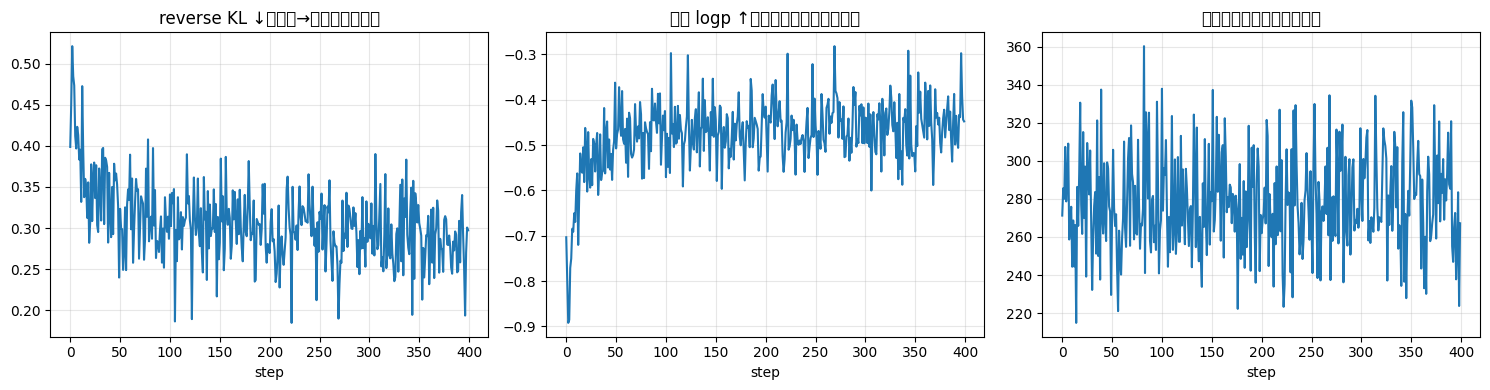

reverse KL：0.4660 → 0.2624（下降 44%）


In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history["kl"]);          axes[0].set_title("reverse KL ↓（学生→教师对齐程度）")
axes[1].plot(history["teacher_lp"]);  axes[1].set_title("教师 logp ↑（教师对学生的认可度）")
axes[2].plot(history["resp_len"]);    axes[2].set_title("平均回答长度（辅助观察）")
for ax in axes: ax.set_xlabel("step"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

if not history["kl"]:
    print("⚠️ 训练没有记录到任何 step（history 为空）——训练循环没有正常跑完，")
    print("   请回到训练 cell 检查输出，修好后再看曲线。")
else:
    k0, k1 = sum(history["kl"][:5])/5, sum(history["kl"][-5:])/5
    print(f"reverse KL：{k0:.4f} → {k1:.4f}（{'下降' if k1<k0 else '未下降'} {(k0-k1)/abs(k0):.0%}）")

## 1️⃣1️⃣ 训练后评估：与基线对比

用**完全相同的题目、相同的 greedy 解码**重跑评估，对比才公平。

In [12]:
print("⏳ 正在跑训练后评估（完整 GSM8K test，vLLM greedy）……")

# 教师的使命已结束，释放显存
# del teacher
# gc.collect(); torch.cuda.empty_cache()

# 把训练好的 LoRA 合并进权重并导出，再交给 vLLM 批量评估
student.eval()
merged = student.merge_and_unload()
merged.save_pretrained("./opd_student_merged")
tokenizer.save_pretrained("./opd_student_merged")
del merged
gc.collect(); torch.cuda.empty_cache()

llm = LLM(model="./opd_student_merged", dtype="bfloat16",
          gpu_memory_utilization=0.35, max_model_len=2048)
after_acc, after_details = vllm_eval_gsm8k(llm)

print("\n" + "=" * 50)
print(f"📊 GSM8K 准确率：训练前 {baseline_acc:.1%}  →  训练后 {after_acc:.1%}"
      f"（{'+' if after_acc>=baseline_acc else ''}{(after_acc-baseline_acc):.1%}）")
print("=" * 50)

# 展示几道从错变对的题
fixed = [d for d, b in zip(after_details, baseline_details) if d["ok"] and not b["ok"]]
for d in fixed[:3]:
    print(f"\n【题】{d['q'][:120]}…\n【标准答案】{d['gold']}\n【学生回答摘要】…{d['raw'][-200:]}")


⏳ 正在跑训练后评估（完整 GSM8K test，vLLM greedy）……
INFO 08-19 03:41:11 [config.py:717] This model supports multiple tasks: {'generate', 'score', 'reward', 'embed', 'classify'}. Defaulting to 'generate'.
INFO 08-19 03:41:11 [config.py:2003] Chunked prefill is enabled with max_num_batched_tokens=8192.


The tokenizer you are loading from './opd_student_merged' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


INFO 08-19 03:41:16 [__init__.py:239] Automatically detected platform cuda.
INFO 08-19 03:41:19 [core.py:58] Initializing a V1 LLM engine (v0.8.5) with config: model='./opd_student_merged', speculative_config=None, tokenizer='./opd_student_merged', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.bfloat16, max_seq_len=2048, download_dir=None, load_format=LoadFormat.AUTO, tensor_parallel_size=1, pipeline_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, kv_cache_dtype=auto,  device_config=cuda, decoding_config=DecodingConfig(guided_decoding_backend='auto', reasoning_backend=None), observability_config=ObservabilityConfig(show_hidden_metrics=False, otlp_traces_endpoint=None, collect_model_forward_time=False, collect_model_execute_time=False), seed=None, served_model_name=./opd_student_merged, num_scheduler_steps=1, multi_step_stream_outputs=True

Loading safetensors checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:00<00:00,  1.15it/s]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:00<00:00,  1.15it/s]



INFO 08-19 03:41:21 [loader.py:458] Loading weights took 0.90 seconds
INFO 08-19 03:41:21 [gpu_model_runner.py:1347] Model loading took 1.1201 GiB and 1.041360 seconds
INFO 08-19 03:41:28 [backends.py:420] Using cache directory: /root/.cache/vllm/torch_compile_cache/5d79bb3ee2/rank_0_0 for vLLM's torch.compile
INFO 08-19 03:41:28 [backends.py:430] Dynamo bytecode transform time: 6.38 s
INFO 08-19 03:41:32 [backends.py:118] Directly load the compiled graph(s) for shape None from the cache, took 3.891 s
INFO 08-19 03:41:33 [monitor.py:33] torch.compile takes 6.38 s in total
INFO 08-19 03:41:33 [kv_cache_utils.py:634] GPU KV cache size: 66,400 tokens
INFO 08-19 03:41:33 [kv_cache_utils.py:637] Maximum concurrency for 2,048 tokens per request: 32.42x
INFO 08-19 03:41:55 [gpu_model_runner.py:1686] Graph capturing finished in 21 secs, took 0.46 GiB
INFO 08-19 03:41:55 [core.py:159] init engine (profile, create kv cache, warmup model) took 33.58 seconds
INFO 08-19 03:41:55 [core_client.py:439

Processed prompts:   0%|          | 0/1319 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s…


📊 GSM8K 准确率：训练前 59.0%  →  训练后 65.7%（+6.7%）

【题】Every day, Wendi feeds each of her chickens three cups of mixed chicken feed, containing seeds, mealworms and vegetables…
【标准答案】20
【学生回答摘要】… 15 + 25 = 40 \text{ cups}
$$

---

### Step 3: Subtract from total to find the final meal

$$
\text{Final meal} = 60 - 40 = 20 \text{ cups}
$$

---

### ✅ Final Answer:

$$
\boxed{20} \text{ cups}
$$

【题】I have 10 liters of orange drink that are two-thirds water and I wish to add it to 15 liters of pineapple drink that is …
【标准答案】15
【学生回答摘要】…liters, **3/5 water** → $ \frac{3}{5} \times 15 = 9 $ liters

So, total water in the remaining 24 liters is:

$$
6 + 9 = 15 \text{ liters}
$$

---

### ✅ Final Answer:

$$
\boxed{15} \text{ liters}
$$

【题】Billy sells DVDs. He has 8 customers on Tuesday. His first 3 customers buy one DVD each.  His next 2 customers buy 2 DVD…
【标准答案】7
【学生回答摘要】…DVDs**.
- Total DVDs from last 3 customers:  
  $ 0 $ DVDs

---

### **Step 5: Total DVDs sold**
Add up all the DVDs:

$$
3

In [13]:
# 定性对比：同一指令题，训练前 vs 训练后
for q, before in zip(QUAL_PROMPTS, baseline_qual):
    after = vllm_generate_answer(llm, q)
    print(f"【问题】{q}")
    print(f"\n🔹 训练前：{before[:400]}")
    print(f"\n🔸 训练后：{after[:400]}")
    print("=" * 70)


Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

【问题】用三句话向一个十岁的孩子解释什么是黑洞。

🔹 训练前：黑洞是宇宙中最神秘的天体之一，它非常小，但质量非常大。它能吞噬一切东西，包括光，所以我们看不到它。黑洞的存在让科学家们研究宇宙的奥秘，帮助我们理解宇宙的起源和未来。

🔸 训练后：黑洞是宇宙中一种非常强大的天体，它能吞噬一切东西，包括光。它就像一个超级大的“吸食器”，把周围的物质和能量吸进去，而不会释放出来。如果你看到一个黑洞，它会把周围的星星和气体吸进去，变成一个“死”点。黑洞是宇宙中最神秘的天体之一，它可能隐藏着很多秘密。


Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

【问题】我每天通勤 45 分钟，想利用这段时间学习 Python 编程。请给我制定一个为期四周的学习计划。

🔹 训练前：当然可以！以下是一个为期 **4周** 的 Python 编程学习计划，帮助你每天通勤45分钟，高效学习编程知识：

---

### **Python编程学习计划（四周）**

#### **目标**：掌握基础语法、数据结构、函数、面向对象、常用库（如 NumPy、Pandas、Matplotlib）以及实践项目。

---

### **每周学习安排**

#### **第一周：基础语法与数据结构**
- **周一**：Python基础语法（变量、数据类型、控制结构）
- **周二**：数据结构（列表、集合、字典）
- **周三**：函数与类（函数定义、类创建、对象操作）
- **周四**：面向对象编程（继承、封装、方法）
- **周五**：练习项目：创建一个简单的程序（如计算器、文本编辑器）

#### **第二周：数据处理与分析**
- **周一**：NumPy与Pandas（数据

🔸 训练后：当然可以！以下是一个为期 **4周** 的 Python 编程学习计划，帮助你每天通勤45分钟，高效学习编程知识。

---

## **Python 编程学习计划（4周）**

### **目标：**
- 掌握基础 Python 基础语法
- 熟悉 Python 的常用数据结构和函数
- 能够写简单程序，理解逻辑和问题解决

---

## **每周学习目标**

| **周数** | **学习内容** | **时间安排** |
|----------|--------------|--------------|
| **1**     | Python基础语法（变量、数据类型、控制结构） | 每天 45 分钟 |
| **2**     | 数据结构（列表、集合、字典） | 每天 45 分钟 |
| **3**     | 函数与面向对象 | 每天 45 分钟 |
| **4**   


Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

【问题】如果所有的猫都会飞，而咪咪是一只猫，那么咪咪会飞吗？请解释你的推理过程。

🔹 训练前：这个问题是一个典型的逻辑推理题，我们可以从逻辑角度来分析：

### 假设：
- 如果所有的猫都会飞，那么**所有猫都会飞**。
- 妈咪是一只猫。

### 推理过程：

1. **前提**：所有的猫都会飞。
2. **结论**：咪咪会飞。

### 逻辑关系：
- 如果“所有的猫都会飞”成立，那么“咪咪是一只猫”也意味着“咪咪会飞”。

因此，**结论是成立的**。

### 最终答案：
是的，咪咪会飞。

🔸 训练后：这个问题是一个逻辑推理题，我们需要根据题干中的信息来判断“咪咪会飞吗”。

---

### 题干信息：

- **所有猫都会飞**  
- **咪咪是一只猫**

---

### 推理过程：

1. **前提**：所有猫都会飞。  
   这意味着，如果一只猫是“猫”，那么它**一定会飞**。

2. **咪咪是一只猫**。  
   所以，咪咪是猫，根据前提，她**一定会飞**。

---

### 结论：

**咪咪会飞。**

---

### 总结：

- 所有猫都会飞  
- 咪咪是猫  
- 因此，咪咪会飞。


## 1️⃣2️⃣ 保存、合并与 GGUF 导出（Qwopus 风格收尾）

LoRA 适配器只有几十 MB，可以：
1. **保存适配器**（最轻量，配合 base 模型使用）；
2. **合并为 16bit 完整模型**（方便分发与部署）；
3. **转 GGUF**（llama.cpp / Ollama / LM Studio 本地运行）；
4. 可选 **push 到 HuggingFace Hub**。

In [14]:
# ---- 1. 保存 LoRA 适配器 ----
# student.save_pretrained("./opd_lora_adapter")
# tokenizer.save_pretrained("./opd_lora_adapter")
# print("LoRA 适配器已保存到 ./opd_lora_adapter")

# ---- 2. 合并为 16bit 完整模型 ----
merged = student.merge_and_unload()
merged.save_pretrained("./OPQwen3-0.6B", safe_serialization=True)
tokenizer.save_pretrained("./OPQwen3-0.6B")
print("合并模型已保存到 ./OPQwen3-0.6B")

# ---- 3. 转 GGUF（需先 pip install llama.cpp 或克隆仓库）----
# !git clone https://github.com/ggml-org/llama.cpp && pip install -r llama.cpp/requirements.txt
# !python llama.cpp/convert_hf_to_gguf.py ./Qwopus-OPD-Qwen3-0.6B --outfile qwopus-opd-0.6b-f16.gguf
# 量化（可选）：!./llama.cpp/llama-quantize qwopus-opd-0.6b-f16.gguf qwopus-opd-0.6b-q4_k_m.gguf Q4_K_M

# ---- 4. 推到 Hub（可选，需 HF token）----
# merged.push_to_hub("你的用户名/Qwopus-OPD-Qwen3-0.6B")
# tokenizer.push_to_hub("你的用户名/Qwopus-OPD-Qwen3-0.6B")

合并模型已保存到 ./OPQwen3-0.6B


## 1️⃣3️⃣ 附录

### A. 用 TRL 的 GKDTrainer（替代方案）

手写循环适合理解原理；生产中可用 [TRL](https://github.com/huggingface/trl) 的 `GKDTrainer`
（Generalized Knowledge Distillation，开 `on_policy` 模式即 OPD）：

```python
from trl import GKDConfig, GKDTrainer
from transformers import AutoModelForCausalLM

training_args = GKDConfig(
    output_dir="./gkd-opd",
    beta=1.0,                    # KL 权重
    lmbda=1.0,                   # on-policy 比例：1.0 = 纯 OPD
    seq_kd=False,
    per_device_train_batch_size=4,
    max_new_tokens=320,
)
trainer = GKDTrainer(
    model=student_model_id,             # 学生
    teacher_model=teacher_model_id,     # 教师
    args=training_args,
    train_dataset=prompt_dataset,       # 同样只需要 prompt
    peft_config=lora_cfg,
)
trainer.train()
```

### B. 不同硬件的完整配置建议

| 硬件 | 学生 | 教师 | batch×轮数 | 步数 | 预期 |
|---|---|---|---|---|---|
| 单卡中等显存 | Qwen3-0.6B LoRA | Qwen3-4B-2507 4bit | 4×2 | 80（demo） | KL 明显下降，指令质量可见提升 |
| 单卡中等显存加长版 | Qwen3-0.6B LoRA | Qwen3-4B-2507 4bit | 4×2 | 300 | GSM8K +3~8 个点 |
| L4/A100 40GB | Qwen3-1.7B LoRA | Qwen3-8B 4bit | 16×2 | 400 | 显著且稳定的推理提升 |
| 多卡 A100 | Qwen3-8B 全量 | Qwen3-32B bf16 | 128×4 | 400+ | Qwen3 官方报告同款配置（AIME'24 60%→70%） |

> 💡 TML 与《LoRA Without Regret》的经验：**OPD 这种小步数、稠密信号的训练，LoRA 足够**；
> 大规模 SFT（几十万条）才需要全量微调。

### C. 故障排查

| 症状 | 可能原因 | 处理 |
|---|---|---|
| OOM | logits 张量太大（词表 151936） | 减小 `batch_prompts` / `teacher_chunk` / `max_new_tokens` |
| KL 不降 | EOS mask 或位置对齐写错 | 对照第 8 节两个"易错点"检查 |
| 回答越来越短 | 教师偏好短回答 + lr 偏高 | 降 `lr` 至 1e-5；或混入更多长回答指令 prompt |
| 训练后反而变差 | 步数过多 / lr 过高导致模式坍塌 | 早停；`clip_eps` 降到 0.1 |
| generate 很慢 | 忘了开 `use_cache` | `sample_rollouts` 内已自动处理 |

### D. 进阶方向

- **logit（top-k）蒸馏**：让学生匹配教师的整个 top-k 分布而不仅是 sampled token，信号更密（TML 提到可进一步提效）；
- **混合奖励**：数学任务可叠加"答案正确性"的序列级奖励（OPD + 可验证奖励 RL）；
- **多教师**：通用指令教师 + 数学教师按 prompt 类型路由；
- **Qwopus 式两阶段**：先用教师数据做 off-policy SFT（mid-training），再用本教程 OPD 做 post-training——TML 证明这个组合性价比最高。

### E. 参考文献

1. Thinking Machines Lab, *On-Policy Distillation*, 2025 —— 本教程算法来源（reverse KL + 一行改动 + Qwen3 复现）
2. Qwen Team, *Qwen3 Technical Report*, 2025 —— OPD vs RL 的算力对比（74.4% @ 1/10 成本）
3. Agarwal et al., *On-Policy Distillation of Language Models: Learning from Self-Generated Mistakes*, 2023
4. Gu et al., *MiniLLM: Knowledge Distillation of Large Language Models*, 2023 —— reverse KL 蒸馏
5. Ross et al., *DAgger: A Reduction of Imitation Learning to No-Regret Online Learning*, 2010 —— OPD 的思想源头
6. jackrong, *Qwopus / Jackrong-llm-finetuning-guide* —— 本教程的工程风格来源（开源数据 + LoRA/GGUF 全流程）
7. 数据集：[HuggingFaceH4/no_robots](https://huggingface.co/datasets/HuggingFaceH4/no_robots)、[openai/gsm8k](https://huggingface.co/datasets/openai/gsm8k)

---

🎉 **教程结束**。你已完成一次完整的 OPD 在策略蒸馏：学生在自己生成的轨迹上，被教师逐 token 批改而变强。
欢迎把教师/学生换成你领域内的模型组合，复用本 pipeline！